# Logistic Regression: Full Engineered Feature Set

Identical to notebook 04 but using `shot_logs_cleaned_engineered.csv`, which includes all features created in notebook 02: shot-type flags (`three_pointer`, `paint`, `mid_range`, `iso`), composite indices (`defender_distance_ratio`, `time_pressure_index`, `creation_load_log`), and binary context flags (`early_clock_indicator`, `pull_up`). Goal is to measure how much the engineered features move the needle over the baseline AUC of 0.630.

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working directory:", Path.cwd())

Working directory: c:\Users\micha\Downloads\CS158\Shot-Value-Machine-Learning


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, log_loss,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)

# load engineered feature set (produced in notebook 02)
df = pd.read_csv("data/processed/shot_logs_cleaned_engineered.csv")

In [3]:
# full feature set: notebook 04 features + all engineered additions from notebook 02
features = [
    # raw shot context (same as notebook 04)
    "shot_dist",
    "close_def_dist",
    "shot_clock",
    "dribbles",
    "touch_time",
    "pts_type",
    "period",
    # engineered: nonlinear and interaction terms (same as notebook 04)
    "game_clock_pct",
    "def_dist_x_shot_dist",
    "shot_dist_squared",
    # engineered: shot-type flags (new)
    "catch_and_shoot",
    "dribble_pull_up",
    "pull_up",
    "three_pointer",
    "paint",
    "mid_range",
    "iso",
    # engineered: composite indices (new)
    "shot_clock_pct",
    "defender_distance_ratio",
    "time_pressure_index",
    "early_clock_indicator",
    "creation_load_log",
]

X = df[features].copy()
# encode location as binary: H=1, A=0
X["location"] = (df["location"] == "H").astype(int)
features = features + ["location"]
y = df["made"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scale for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (102205, 23)
X_test shape:  (25552, 23)


In [4]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression (engineered features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC AUC: ", roc_auc_score(y_test, y_prob_lr))
print("Log Loss:", log_loss(y_test, y_prob_lr))

=== Logistic Regression (engineered features) ===
Accuracy: 0.6113415779586725
ROC AUC:  0.630245282227827
Log Loss: 0.6562633668802683


In [5]:
# coefficient table: which features the model weighted most heavily
coef_df = pd.DataFrame({
    "feature":     X_train.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values(by="coefficient", ascending=False)

coef_df

,feature,coefficient
1,close_def_dist,0.534321
18,defender_distance_ratio,0.223028
9,shot_dist_squared,0.183963
21,creation_load_log,0.152054
10,catch_and_shoot,0.130124
14,paint,0.064721
3,dribbles,0.039835
22,location,0.014852
17,shot_clock_pct,0.013762
2,shot_clock,0.013762


In [6]:
# direct comparison against notebook 04 baseline (8-feature logistic regression)
comparison = pd.DataFrame([
    {"Model": "LR — Baseline (notebook 04)",   "Accuracy": 0.609, "ROC AUC": 0.630, "Log Loss": 0.657},
    {"Model": "LR — Engineered (notebook 06)", "Accuracy": accuracy_score(y_test, y_pred_lr),
                                                "ROC AUC": roc_auc_score(y_test, y_prob_lr),
                                                "Log Loss": log_loss(y_test, y_prob_lr)},
]).set_index("Model").round(4)

comparison

,Accuracy,ROC AUC,Log Loss
Model,,,
LR — Baseline (notebook 04),0.6090,0.6300,0.6570
LR — Engineered (notebook 06),0.6113,0.6302,0.6563


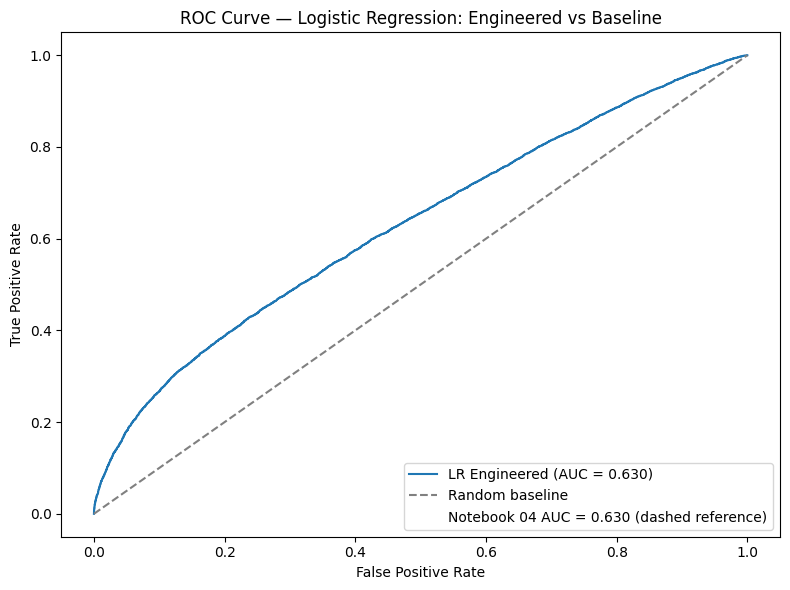

In [7]:
# ROC curve for this model vs the notebook 04 baseline AUC reference line
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"LR Engineered (AUC = {roc_auc:.3f})")
plt.axhline(y=0, xmin=0, xmax=0)  # invisible anchor
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
# reference point for notebook 04 AUC
plt.axvline(x=0, color="none", label="Notebook 04 AUC = 0.630 (dashed reference)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression: Engineered vs Baseline")
plt.legend()
plt.tight_layout()
plt.show()

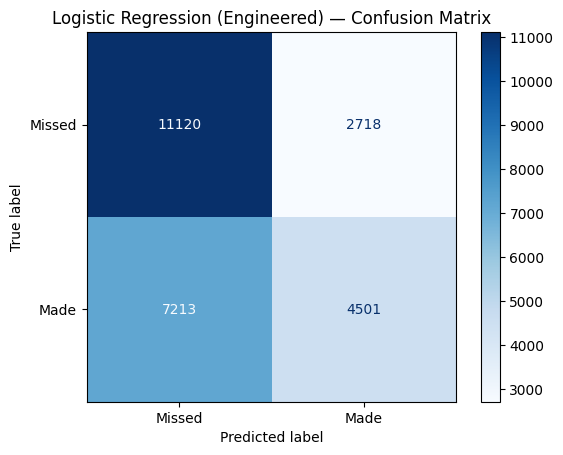

In [8]:
cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Missed", "Made"]).plot(cmap="Blues")
plt.title("Logistic Regression (Engineered) — Confusion Matrix")
plt.show()

## Summary

Adding the full engineered feature set to logistic regression produced virtually no improvement over the 8-feature baseline from notebook 04:

| Model | Accuracy | ROC AUC | Log Loss |
|---|---|---|---|
| LR — Baseline (nb04) | 0.6090 | 0.6300 | 0.6570 |
| LR — Engineered (nb06) | 0.6113 | 0.6302 | 0.6563 |

AUC improved by just 0.0002 and log loss by 0.0007. This means the additional features (shot-type flags, composite indices, isolation indicators) carry almost no additional information that the baseline's 8 features didn't already capture within a linear model.

Evidently, the performance ceiling around AUC ~0.630–0.642 is not a feature engineering problem. A logistic regression with 8 features and one with 23 features land in the same place, which confirms the bottleneck is unmeasured shooter quality rather than the desired area of focus, shot context complexity.